<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
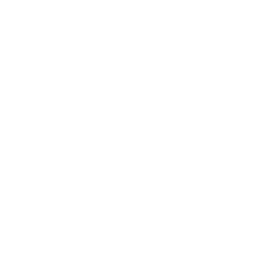
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Klassificering av molekylär subtyp från genuttryck</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioteknik / Genomisk onkologi &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Klassificera tumörbiopsiprover i fyra molekylära subtyper (Luminal-A, Luminal-B, HER2-anrikad, Basal-lik) med hjälp av biomarkörpaneler för genuttryck. Tillämpa kanonisk diskriminantanalys för att reducera det högdimensionella uttrycksrummet till tolkningsbara variationsaxlar. Använd MANOVA för att testa om medeluttrycksprofilerna skiljer sig signifikant mellan subtyperna. Korsvalidera för att uppskatta klassificeringens tillförlitlighet som stöd för kliniska beslut vid val av behandlingsväg.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------|
| WORK.GENE_EXPR | Tumörgenuttryck med subtypsetiketter | 100 |
| WORK.NEW_BIOPSIES | Oklassificerade biopsiprover | 100 |


---

In [1]:
/* --------------------------------------------------------
   Generera syntetiskt genuttrycksdataset
   med fyra molekylära subtyper
   -------------------------------------------------------- */
data work.gene_expr;
    CALL streaminit(42);
    LÄNGD mol_subtype $12;
    FÄLT subtype_list[4] $12 _temporary_ ('LUMINAL_A' 'LUMINAL_B' 'HER2_ENRICH' 'BASAL_LIKE');
    GÖR sample_id = 1 TILL 100;
        tumor_id = cat('TUM-', SKRIV_UT_V(sample_id, z5.));
        sub_idx = int(rand('uniform') * 4) + 1;
        mol_subtype = subtype_list[sub_idx];

        /* Simulerade genuttrycksmarkörer (log2-skala) */
        VÄLJ (mol_subtype);
            NÄR ('LUMINAL_A') GÖR;
                esr1_expr = round(rand('normal', 11.5, 1.2), 0.01);
                pgr_expr = round(rand('normal', 9.8, 1.5), 0.01);
                erbb2_expr = round(rand('normal', 7.2, 0.9), 0.01);
                ki67_expr = round(rand('normal', 6.0, 1.0), 0.01);
                egfr_expr = round(rand('normal', 6.5, 1.1), 0.01);
                cytokeratin5 = round(rand('normal', 5.0, 0.8), 0.01);
                tp53_mut_load = round(rand('poisson', 1.5), 1);
                prolif_score = round(rand('normal', 3.2, 0.8), 0.01);
            SLUT;
            NÄR ('LUMINAL_B') GÖR;
                esr1_expr = round(rand('normal', 10.0, 1.4), 0.01);
                pgr_expr = round(rand('normal', 7.5, 1.8), 0.01);
                erbb2_expr = round(rand('normal', 8.5, 1.2), 0.01);
                ki67_expr = round(rand('normal', 8.5, 1.2), 0.01);
                egfr_expr = round(rand('normal', 7.0, 1.0), 0.01);
                cytokeratin5 = round(rand('normal', 5.5, 0.9), 0.01);
                tp53_mut_load = round(rand('poisson', 3.0), 1);
                prolif_score = round(rand('normal', 6.0, 1.0), 0.01);
            SLUT;
            NÄR ('HER2_ENRICH') GÖR;
                esr1_expr = round(rand('normal', 6.5, 1.5), 0.01);
                pgr_expr = round(rand('normal', 5.0, 1.2), 0.01);
                erbb2_expr = round(rand('normal', 13.0, 1.0), 0.01);
                ki67_expr = round(rand('normal', 9.0, 1.3), 0.01);
                egfr_expr = round(rand('normal', 8.5, 1.2), 0.01);
                cytokeratin5 = round(rand('normal', 6.0, 1.0), 0.01);
                tp53_mut_load = round(rand('poisson', 5.0), 1);
                prolif_score = round(rand('normal', 7.5, 1.1), 0.01);
            SLUT;
            NÄR ('BASAL_LIKE') GÖR;
                esr1_expr = round(rand('normal', 4.5, 1.3), 0.01);
                pgr_expr = round(rand('normal', 3.8, 1.0), 0.01);
                erbb2_expr = round(rand('normal', 6.0, 1.1), 0.01);
                ki67_expr = round(rand('normal', 10.5, 1.4), 0.01);
                egfr_expr = round(rand('normal', 11.0, 1.3), 0.01);
                cytokeratin5 = round(rand('normal', 10.5, 1.2), 0.01);
                tp53_mut_load = round(rand('poisson', 7.0), 1);
                prolif_score = round(rand('normal', 8.8, 1.2), 0.01);
            SLUT;
            ANNARS_OM;
        SLUT;
        UTDATA;
    SLUT;
    ETIKETT mol_subtype = 'Molekylär subtyp'
          esr1_expr = 'ESR1-uttryck (log2)'
          pgr_expr = 'PGR-uttryck (log2)'
          erbb2_expr = 'ERBB2-uttryck (log2)'
          ki67_expr = 'Ki67-uttryck (log2)'
          egfr_expr = 'EGFR-uttryck (log2)'
          cytokeratin5 = 'Cytokeratin-5 (log2)'
          tp53_mut_load = 'TP53-mutationsbörda'
          prolif_score = 'Proliferationspoäng';
    TA_BORT sub_idx;
KÖR;


NOTE: DATA work.gene_expr


NOTE: Wrote work.gene_expr (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Generera oklassificerade biopsiprover
   -------------------------------------------------------- */
data work.new_biopsies;
    CALL streaminit(55);
    GÖR sample_id = 5001 TILL 5100;
        tumor_id = cat('TUM-', SKRIV_UT_V(sample_id, z5.));
        esr1_expr = round(rand('normal', 8.0, 3.0), 0.01);
        pgr_expr = round(rand('normal', 6.5, 3.0), 0.01);
        erbb2_expr = round(rand('normal', 8.5, 2.5), 0.01);
        ki67_expr = round(rand('normal', 8.0, 2.0), 0.01);
        egfr_expr = round(rand('normal', 8.0, 2.0), 0.01);
        cytokeratin5 = round(rand('normal', 7.0, 2.5), 0.01);
        tp53_mut_load = round(rand('poisson', 4.0), 1);
        prolif_score = round(rand('normal', 6.0, 2.5), 0.01);
        mol_subtype = '';
        UTDATA;
    SLUT;
KÖR;


NOTE: DATA work.new_biopsies


NOTE: Wrote work.new_biopsies (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                           Fördelning av molekylära subtyper                                            

                                                   The FREQ Procedure

Molekylär subtyp     Frequency    Percent
------------------------------------------
BASAL_LIKE                  24     24.00
HER2_ENRICH                 22     22.00
LUMINAL_A                   25     25.00
LUMINAL_B                   29     29.00
                                   Sammanfattning av genuttryck per molekylär subtyp                                    

                                                  The MEANS Procedure

                                   Analysis Variable : esr1_expr ESR1-uttryck (log2)

        Molekylär subtyp           N Obs           Mean        Std Dev
        --------------------------------------------------------------
        BASAL_LIKE                    24      4.5479167      1.2257100
        HER2_ENRICH                   22      7.1318182      1.448


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mol_subtype.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


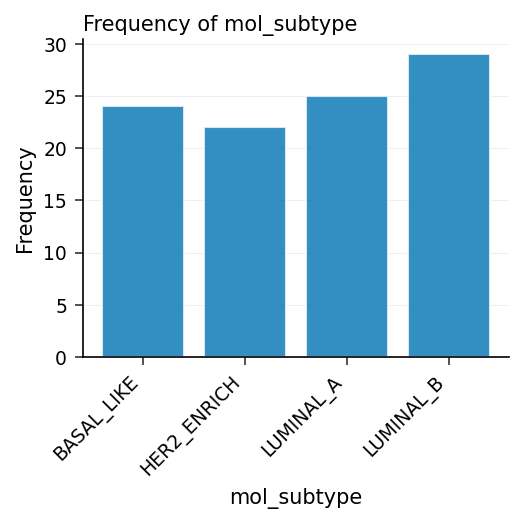

In [3]:
/* --------------------------------------------------------
   Baslinjefördelning av subtyper och uttrycksprofiler
   -------------------------------------------------------- */
PROCEDUR FREKVENSER data=work.gene_expr;
    TABLES mol_subtype / nocum;
    ETIKETT mol_subtype = 'Molekylär subtyp';
    TITEL 'Fördelning av molekylära subtyper';
KÖR;

PROCEDUR MEDELVÄRDEN data=work.gene_expr n mean std;
    KLASS mol_subtype;
    VARIABEL esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    ETIKETT mol_subtype = 'Molekylär subtyp'
          esr1_expr = 'ESR1-uttryck (log2)'
          pgr_expr = 'PGR-uttryck (log2)'
          erbb2_expr = 'ERBB2-uttryck (log2)'
          ki67_expr = 'Ki67-uttryck (log2)'
          egfr_expr = 'EGFR-uttryck (log2)'
          cytokeratin5 = 'Cytokeratin-5 (log2)'
          tp53_mut_load = 'TP53-mutationsbörda'
          prolif_score = 'Proliferationspoäng';
    TITEL 'Sammanfattning av genuttryck per molekylär subtyp';
KÖR;

---

In [4]:
/* --------------------------------------------------------
   Kanonisk diskriminantanalys med MANOVA
   CANONICAL extraherar diskriminantaxlar för visualisering.
   MANOVA testar den övergripande medelseparationen mellan subtyper.
   -------------------------------------------------------- */
PROCEDUR DISCRIM data=work.gene_expr
        METHOD=NORMAL
        pool=TEST
        canonical
        MANOVA
        crossvalidate
        out=work.subtype_canonical
        OUTSTAT=work.subtype_stats;
    KLASS mol_subtype;
    VARIABEL esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    TITEL 'Kanonisk diskriminantanalys: molekylära tumörsubtyper';
    title2 'MANOVA-test av skillnader i medeluttrycksprofiler';
KÖR;

                                   Sammanfattning av genuttryck per molekylär subtyp                                    


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Cross-Validation Error Rate: 0.0400
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: Multivariate Statistics:
NOTE:   Wilks' Lambda: 0.0037 (p = 0.000000)
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


---

                                   Sammanfattning av genuttryck per molekylär subtyp                                    




NOTE: PROC SGPLOT data=work.subtype_canonical

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


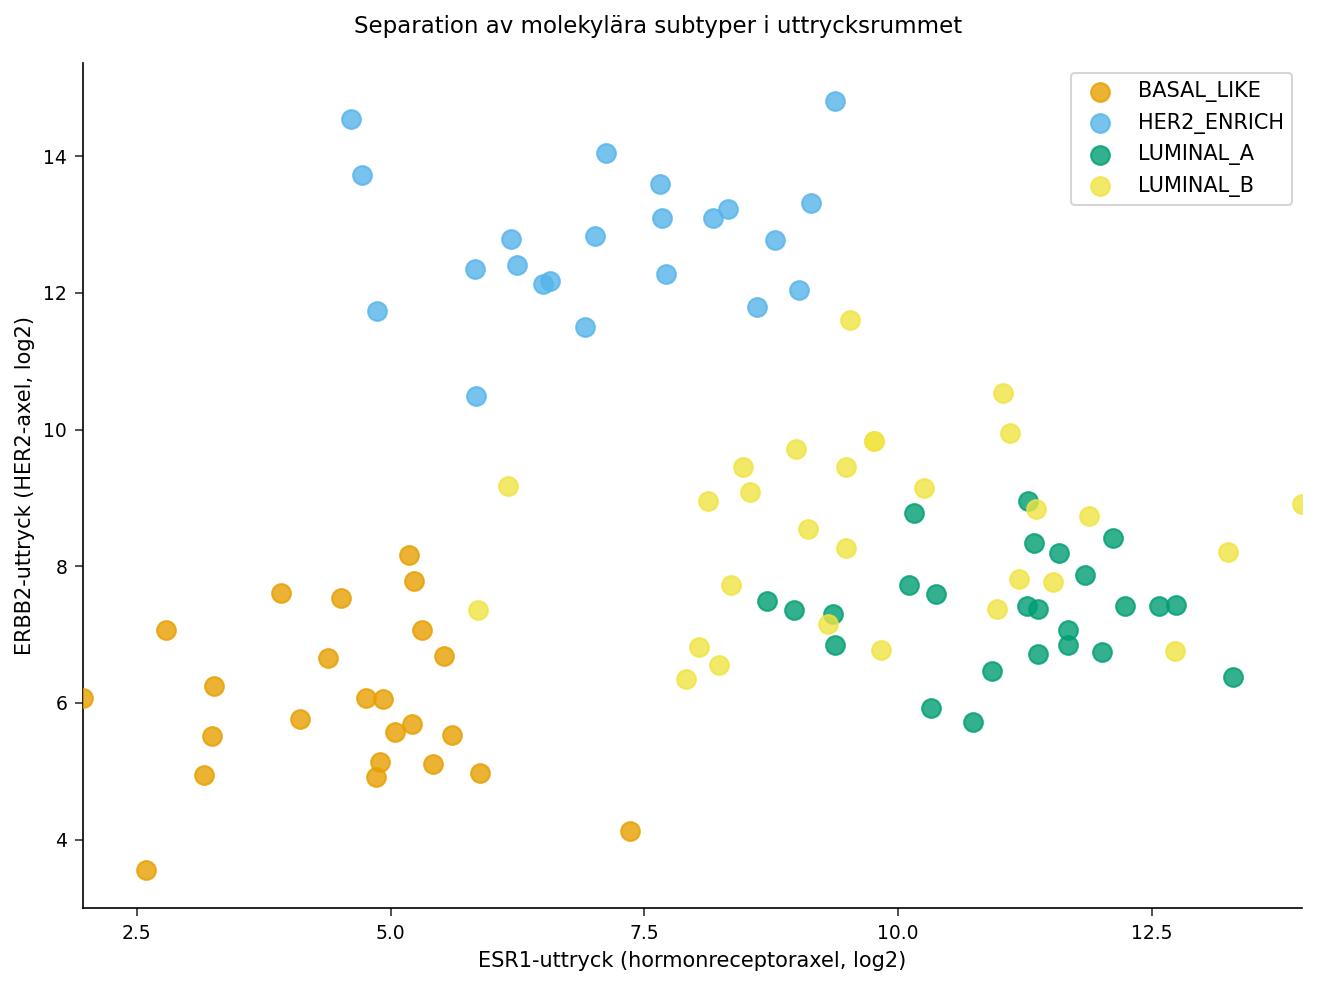

In [5]:
/* --------------------------------------------------------
   Subtypsseparation i uttrycksrummet
   ESR1 (hormonreceptoraxel) mot ERBB2 (HER2-axel),
   hämtade ur DISCRIM:s OUT=-dataset.
   -------------------------------------------------------- */
PROCEDUR SGPLOT data=work.subtype_canonical;
    SCATTER x=esr1_expr y=erbb2_expr / GROUP=mol_subtype
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.2;
    XAXIS ETIKETT='ESR1-uttryck (hormonreceptoraxel, log2)';
    YAXIS ETIKETT='ERBB2-uttryck (HER2-axel, log2)';
    TITEL 'Separation av molekylära subtyper i uttrycksrummet';
KÖR;

In [6]:
/* --------------------------------------------------------
   Klassificera otypade biopsiprover
   -------------------------------------------------------- */
PROCEDUR DISCRIM data=work.gene_expr
        testdata=work.new_biopsies
        testout=work.classified_biopsies
        METHOD=NORMAL
        pool=TEST
        canonical;
    KLASS mol_subtype;
    VARIABEL esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    TITEL 'Klassificering av molekylär subtyp för nya biopsier';
KÖR;

                                   Sammanfattning av genuttryck per molekylär subtyp                                    


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


                              Predikterad fördelning av molekylära subtyper: nya biopsier                               

                                                   The FREQ Procedure

Predikterad subtyp    Frequency    Percent
-------------------------------------------
BASAL_LIKE                    7      7.00
HER2_ENRICH                  47     47.00
LUMINAL_A                    10     10.00
LUMINAL_B                    36     36.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq__into_.spec.json
NOTE: PROC FREQ statement used.


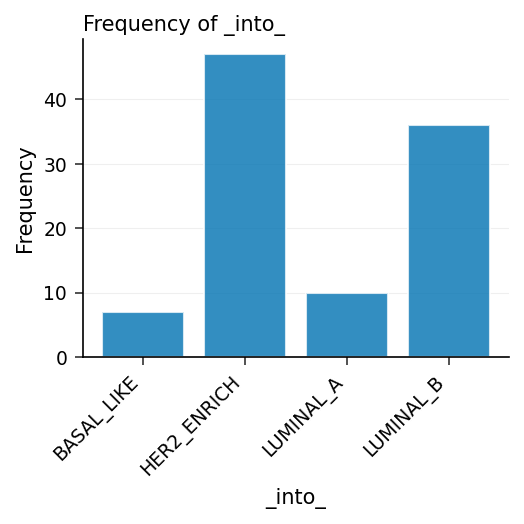

In [7]:
/* --------------------------------------------------------
   Klassificeringsfördelning för nya biopsier
   -------------------------------------------------------- */
PROCEDUR FREKVENSER data=work.classified_biopsies;
    TABLES _into_ / nocum;
    ETIKETT _into_ = 'Predikterad subtyp';
    TITEL 'Predikterad fördelning av molekylära subtyper: nya biopsier';
KÖR;

---

### Tolkning

MANOVA-testet bekräftar en högst signifikant skillnad i medelgenuttrycksprofilerna mellan de fyra molekylära subtyperna: Wilks' Lambda = 0.0037 med p < 0.0001, vilket innebär att subtyperna upptar tydligt åtskilda regioner i uttrycksrummet med åtta markörer. Denna separation syns i spridningsdiagrammet över uttrycksrummet, där Luminaltumörer ligger högt på ESR1-axeln (hormonreceptor) medan HER2-anrikade tumörer trycks upp mot toppen av ERBB2-axeln och Basal-lika tumörer hamnar nere till vänster på båda. Resubstitutionsklassificeringen av de 100 etiketterade tumörerna är perfekt (0 % skenbart fel), och korsvalidering med utelämning av ett prov i taget (leave-one-out) placerar felfrekvensen på bara 4 % — en ärlig korsvaliderad träffsäkerhet på 96 %, där varje subtyp återfinns korrekt i den korsvaliderade förväxlingsmatrisen. När den tränade klassificeraren tillämpas på de 100 oetiketterade biopsierna tilldelas 47 till HER2-anrikad, 36 till Luminal-B, 10 till Luminal-A och 7 till Basal-lik; övervikten mot HER2-anrikad speglar biopsipanelens förhöjda ERBB2- och proliferationsvärden. Dessa subtypsbedömningar styr valet av behandlingsväg: endokrin terapi för Luminaltumörer, riktade anti-HER2-läkemedel för den HER2-anrikade gruppen och cytostatikaregimer för Basal-lika tumörer.

---

In [8]:
/* --------------------------------------------------------
   Exportera klassificerade biopsier för behandlingsplanering
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.classified_biopsies
    OUTFILE='classified_biopsy_subtypes.csv'
    DBMS=csv REPLACE;
KÖR;

PROCEDUR EXPORTERA data=work.subtype_canonical
    OUTFILE='canonical_subtype_scores.csv'
    DBMS=csv REPLACE;
KÖR;


NOTE: PROC EXPORT data=work.classified_biopsies outfile=classified_biopsy_subtypes.csv

NOTE: Exported 100 rows to classified_biopsy_subtypes.csv.
NOTE: PROC EXPORT data=work.subtype_canonical outfile=canonical_subtype_scores.csv

NOTE: Exported 100 rows to canonical_subtype_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>